# Prompt U-Net Version 332 — Final Model Training

## Summary

**V332 is the final benchmark-selected model**, combining the best individual choices from prior ablations. This time only on mri data and 3000 epochs for faster training

| Component | Choice | Source |
|-----------|--------|--------|
| Architecture | `prompt_unet_313.py` (Float32 + SE Attention) | v316 / v313 |
| Offset | 16 | v316 |
| Loss | `binary_crossentropy` (plain BCE) | v316 — beats DiceBCE in benchmarks |
| Training buffer | 10,000 data points | v330 / v331 |
| Refresh cadence | every 30 epochs (slightly less aggressive than v330/v331's 20) | new |
| Datasets | **NAKO + BraTS-GLI + BraTS-MEN-RT + TopCoW MR** | / |
| Total patients | 208 | v319 |
| Epochs | **3000** | / |

All hyper-parameters are read from the **Hyperparameters** cell below — edit there only.

> This notebook can also be run headless via `train_332.py` in the same directory.

## Setup

In [1]:
import os
import sys
import gc
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import mlflow
import tensorflow as tf

import logging
tf.get_logger().setLevel(logging.ERROR)
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"

print(f"TF  : {tf.__version__}")
print(f"GPUs: {tf.config.list_physical_devices('GPU')}")

I0000 00:00:1778051637.165727     100 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


TF  : 2.21.0
GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## Imports

In [2]:
# Allow importing from project root
notebook_dir = Path().resolve()
project_root  = notebook_dir.parent
sys.path.insert(0, str(project_root))

from data.DataLoader_npz import DataLoader_npz
from data.DataGenerator  import DataGenerator

from utils.augmentations  import PromptUNetAugmenter
from utils.metrics        import dice_score_tf
from utils.visualization  import plot_result

from training.prompt_unet_313 import PromptUNet   # v313 architecture (Float32 + SE Attention)
from training.optimizer       import PromptUNetOptimizer

## Data Loading

208 patients total (v316 base + TopCoW from v319).

In [3]:
dataset_paths = [
    "data/train_data/nako_combined.npz",       # 61 PIDs
    # "data/train_data/total_seg_combined.npz",  # 45 PIDs
    # "data/train_data/msd_combined.npz",        # 40 PIDs
    "data/train_data/brats_gli.npz",           # 20 PIDs
    "data/train_data/brats_men_rt.npz",        #  6 PIDs
    "data/train_data/TopCoW_MR.npz",           # 18 PIDs  (from v319)
    # "data/train_data/TopCoW_CT.npz",           # 18 PIDs  (from v319)
]  # Total: 208 patients

dataloader    = DataLoader_npz(dataset_paths, val_size=0.01)
datagenerator = DataGenerator(dataloader)

print(f"Image size: {datagenerator.height} x {datagenerator.width}")


Loading NPZ dataset(s)…
Loaded 61 PIDs from /home/dpxuser/prompt-unet/data/train_data/nako_combined.npz
Loaded 20 PIDs from /home/dpxuser/prompt-unet/data/train_data/brats_gli.npz
Loaded 6 PIDs from /home/dpxuser/prompt-unet/data/train_data/brats_men_rt.npz
Loaded 18 PIDs from /home/dpxuser/prompt-unet/data/train_data/TopCoW_MR.npz

Final dataset size: 105 patients.

Image size: 128 x 128


## Hyperparameters

In [4]:
version           = "p_unet_332_mri"

epochs            = 3000
batch_size        = 128
dp_training       = 10000  # 10 k points per buffer refresh (from v330)
dp_testing        = 1000

offset            = 16     # slice-distance offset (from v316)
max_number_labels = 4

new_ds       = 30    # refresh training data every N epochs (slightly less aggressive than v330/v331's 20)
new_val_loop = 300   # run validation every N epochs

# LR schedule phases
warmup_epochs = 50
flat_epochs   = 1500

## Model & Optimizer

`WarmupFlatCosineDecay` schedule (from `optimizer.py`):
- Phase 1 (50 ep): linear warmup 1e-6 → 1e-3  
- Phase 2 (1500 ep): flat plateau at 1e-3  
- Phase 3 (2450 ep): cosine decay 1e-3 → 1e-5

Loss: **plain `binary_crossentropy`** — reverted from DiceBCE (v316 outperforms v330/v331 in benchmarks).

In [5]:
# ── Build model ────────────────────────────────────────────────────────────
model = PromptUNet(height=datagenerator.height, width=datagenerator.width)
# Loss stays as default binary_crossentropy (set inside PromptUNet.__init__)

# Warm-up forward pass to fully initialise all layers
_dummy_x = tf.random.uniform([1, datagenerator.height, datagenerator.width, 1])
_dummy_p = tf.random.uniform([1, datagenerator.height, datagenerator.width, 2])
_ = model.this([_dummy_x, _dummy_p])

print(f"Trainable params: {model.this.count_params():,}")

# ── Build optimizer (imported from optimizer.py) ───────────────────────────
opt_builder = PromptUNetOptimizer(
    epochs        = epochs,
    batch_size    = batch_size,
    dp_training   = dp_training,
    warmup_epochs = warmup_epochs,
    flat_epochs   = flat_epochs,
)
model.optimizer   = opt_builder.get_optimizer()
steps_per_epoch   = opt_builder.steps_per_epoch

I0000 00:00:1778051781.935100     100 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 46640 MB memory:  -> device: 0, name: NVIDIA RTX A6000, pci bus id: 0000:81:00.0, compute capability: 8.6
I0000 00:00:1778051785.035763     100 cuda_dnn.cc:461] Loaded cuDNN version 91002


Trainable params: 28,037,637


## Augmentation Pipeline

Same probabilities as v313–v316.

In [6]:
augmenter = PromptUNetAugmenter(
    prob_photo             = 0.45,
    prob_gamma             = 0.35,
    prob_noise             = 0.40,
    prob_independent_noise = 0.50,
    prob_geometric         = 0.50,
    prob_morph             = 0.30,
    prob_dropout           = 0.40,
    prob_false_pos         = 0.60,
    gamma_range                 = (0.85, 1.25),
    noise_std_range             = (0.0, 0.10),
    independent_noise_std_range = (0.0, 0.01),
)

## Persistent tf.data Pipeline

The pipeline graph (including `.map(augmenter)`) is built **once** here.  
When fresh training data is needed, only the numpy buffer is swapped — no TF graph nodes accumulate over time.

In [7]:
# ── Shared numpy buffer ────────────────────────────────────────────────────
_buf = {"x": None, "y": None, "p": None, "m": None}

def refresh_train_data():
    """Pull fresh random training data into the numpy buffer."""
    x_np, y_np, p_np, m_np, _ = datagenerator.get_data_points_numpy(
        max_data_points   = dp_training,
        offset            = offset,
        max_number_labels = max_number_labels,
    )
    _buf["x"] = x_np
    _buf["y"] = y_np
    _buf["p"] = p_np
    _buf["m"] = m_np
    gc.collect()


def _data_gen():
    """Yields one shuffled sample at a time from the numpy buffer."""
    n       = len(_buf["x"])
    indices = np.random.permutation(n)
    for i in indices:
        yield _buf["x"][i], _buf["y"][i], _buf["p"][i], _buf["m"][i]


H, W = datagenerator.height, datagenerator.width

# Build the pipeline graph ONCE for the entire training run
train_ds = (
    tf.data.Dataset.from_generator(
        _data_gen,
        output_signature=(
            tf.TensorSpec(shape=(H, W, 1), dtype=tf.float32),  # image
            tf.TensorSpec(shape=(H, W, 1), dtype=tf.float32),  # label
            tf.TensorSpec(shape=(H, W, 2), dtype=tf.float32),  # prompt
            tf.TensorSpec(shape=(),        dtype=tf.float32),  # modality
        )
    )
    .map(augmenter, num_parallel_calls=tf.data.AUTOTUNE)
    .batch(batch_size, drop_remainder=True)
    .prefetch(tf.data.AUTOTUNE)
)

print("Pipeline ready.")

Pipeline ready.


## Training

/software/anaconda3/envs/machauer/lib/python3.11/site-packages/mlflow/tracking/_tracking_service/utils.py:184: FutureWarning: The filesystem tracking backend (e.g., './mlruns') is deprecated as of February 2026. Consider transitioning to a database backend (e.g., 'sqlite:///mlflow.db') to take advantage of the latest MLflow features. See https://mlflow.org/docs/latest/self-hosting/migrate-from-file-store for migration guidance.
  return FileStore(store_uri, store_uri)
2026/05/06 09:16:45 INFO mlflow.tracking.fluent: Experiment with name 'p_unet_332_mri' does not exist. Creating a new experiment.


Creating new Data Points ...
It took 70 seconds
Creating new Data Points ...
It took 510 seconds


I0000 00:00:1778052391.784879     100 generator_dataset_op.cc:213] Memory patch applied: M_TRIM_THRESHOLD=128 kb was set.
E0000 00:00:1778052413.270884     100 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape infunctional_1/dropout_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


Epoch    1  loss: 0.660526
Epoch    2  loss: 0.390583
Epoch    3  loss: 0.299909
Epoch    4  loss: 0.271225
Epoch    5  loss: 0.246412
Epoch    6  loss: 0.247435
Epoch    7  loss: 0.209806
Epoch    8  loss: 0.192011
Epoch    9  loss: 0.183774
Epoch   10  loss: 0.170586
Epoch   11  loss: 0.156060
Epoch   12  loss: 0.156259
Epoch   13  loss: 0.145667
Epoch   14  loss: 0.135866
Epoch   15  loss: 0.130752
Epoch   16  loss: 0.120201
Epoch   17  loss: 0.115268
Epoch   18  loss: 0.111323
Epoch   19  loss: 0.107811
Epoch   20  loss: 0.105566
Epoch   21  loss: 0.103738
Epoch   22  loss: 0.101443
Epoch   23  loss: 0.100529
Epoch   24  loss: 0.098680
Epoch   25  loss: 0.097206
Epoch   26  loss: 0.096598
Epoch   27  loss: 0.095634
Epoch   28  loss: 0.095251
Epoch   29  loss: 0.095655
Epoch   30  loss: 0.093495


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.60946137..2.2615364].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.611257..2.2102568].


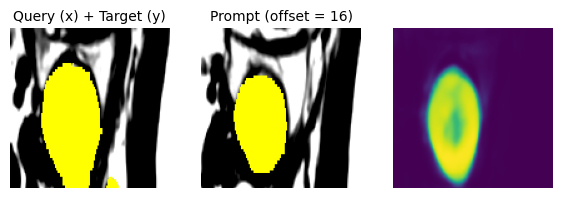

Creating new Data Points ...
It took 695 seconds
Epoch   31  loss: 0.101593
Epoch   32  loss: 0.100333
Epoch   33  loss: 0.098836
Epoch   34  loss: 0.098338
Epoch   35  loss: 0.098458
Epoch   36  loss: 0.098256
Epoch   37  loss: 0.097602
Epoch   38  loss: 0.096691
Epoch   39  loss: 0.097260
Epoch   40  loss: 0.095378
Epoch   41  loss: 0.095431
Epoch   42  loss: 0.094153
Epoch   43  loss: 0.095312
Epoch   44  loss: 0.094489
Epoch   45  loss: 0.094572
Epoch   46  loss: 0.093655
Epoch   47  loss: 0.093730
Epoch   48  loss: 0.093302
Epoch   49  loss: 0.092535
Epoch   50  loss: 0.091938
Epoch   51  loss: 0.091607
Epoch   52  loss: 0.090591
Epoch   53  loss: 0.090493
Epoch   54  loss: 0.089947
Epoch   55  loss: 0.091070
Epoch   56  loss: 0.090580
Epoch   57  loss: 0.088799
Epoch   58  loss: 0.089648
Epoch   59  loss: 0.087958
Epoch   60  loss: 0.090259


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.60946137..2.2615364].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.611257..2.2102568].


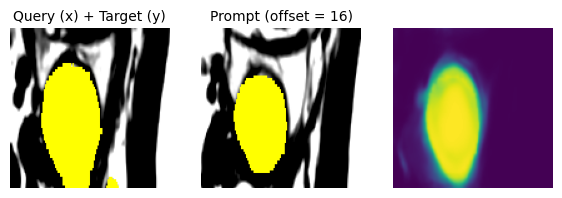

Creating new Data Points ...
It took 685 seconds
Epoch   61  loss: 0.090978
Epoch   62  loss: 0.090217
Epoch   63  loss: 0.089963
Epoch   64  loss: 0.090309
Epoch   65  loss: 0.088789
Epoch   66  loss: 0.089425
Epoch   67  loss: 0.088750
Epoch   68  loss: 0.088428
Epoch   69  loss: 0.088625
Epoch   70  loss: 0.088050
Epoch   71  loss: 0.087266
Epoch   72  loss: 0.086496
Epoch   73  loss: 0.086940
Epoch   74  loss: 0.087372
Epoch   75  loss: 0.086207
Epoch   76  loss: 0.085972
Epoch   77  loss: 0.084953
Epoch   78  loss: 0.086826
Epoch   79  loss: 0.085748
Epoch   80  loss: 0.083920
Epoch   81  loss: 0.085296
Epoch   82  loss: 0.084158
Epoch   83  loss: 0.084275
Epoch   84  loss: 0.084151
Epoch   85  loss: 0.083640
Epoch   86  loss: 0.083656
Epoch   87  loss: 0.083202
Epoch   88  loss: 0.081614
Epoch   89  loss: 0.083583
Epoch   90  loss: 0.082318


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.60946137..2.2615364].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.611257..2.2102568].


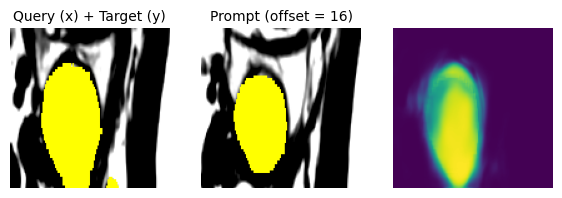

Creating new Data Points ...
It took 618 seconds
Epoch   91  loss: 0.076905
Epoch   92  loss: 0.074397
Epoch   93  loss: 0.074029
Epoch   94  loss: 0.073535
Epoch   95  loss: 0.073821
Epoch   96  loss: 0.073687
Epoch   97  loss: 0.074269
Epoch   98  loss: 0.073202
Epoch   99  loss: 0.073041
Epoch  100  loss: 0.071738
Epoch  101  loss: 0.071512
Epoch  102  loss: 0.071602
Epoch  103  loss: 0.071390
Epoch  104  loss: 0.070787
Epoch  105  loss: 0.070630
Epoch  106  loss: 0.070342
Epoch  107  loss: 0.071092
Epoch  108  loss: 0.070577
Epoch  109  loss: 0.069630
Epoch  110  loss: 0.068906
Epoch  111  loss: 0.069290
Epoch  112  loss: 0.069388
Epoch  113  loss: 0.068452
Epoch  114  loss: 0.068370
Epoch  115  loss: 0.068320
Epoch  116  loss: 0.068144
Epoch  117  loss: 0.067750
Epoch  118  loss: 0.067756
Epoch  119  loss: 0.067238
Epoch  120  loss: 0.065677


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.60946137..2.2615364].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.611257..2.2102568].


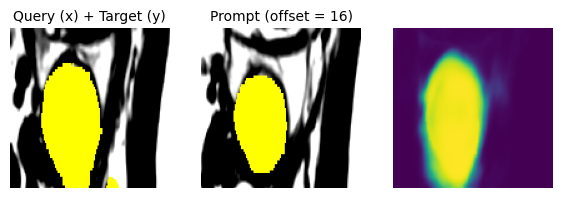

Creating new Data Points ...
It took 456 seconds
Epoch  121  loss: 0.077296
Epoch  122  loss: 0.075013
Epoch  123  loss: 0.073951
Epoch  124  loss: 0.074110
Epoch  125  loss: 0.073164
Epoch  126  loss: 0.072192
Epoch  127  loss: 0.071525
Epoch  128  loss: 0.071186
Epoch  129  loss: 0.071726
Epoch  130  loss: 0.070366
Epoch  131  loss: 0.070458
Epoch  132  loss: 0.071039
Epoch  133  loss: 0.070703
Epoch  134  loss: 0.069603
Epoch  135  loss: 0.069924
Epoch  136  loss: 0.069245
Epoch  137  loss: 0.067910
Epoch  138  loss: 0.068085
Epoch  139  loss: 0.067124
Epoch  140  loss: 0.068063
Epoch  141  loss: 0.068369
Epoch  142  loss: 0.067810
Epoch  143  loss: 0.067150
Epoch  144  loss: 0.066534
Epoch  145  loss: 0.066349
Epoch  146  loss: 0.066396
Epoch  147  loss: 0.067139
Epoch  148  loss: 0.065662
Epoch  149  loss: 0.066305
Epoch  150  loss: 0.066214


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.60946137..2.2615364].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.611257..2.2102568].


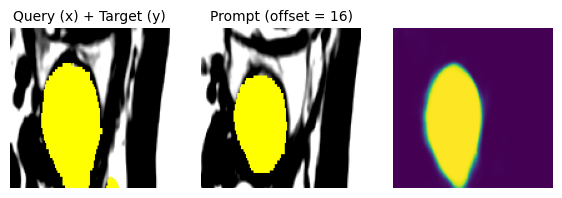

Creating new Data Points ...
It took 458 seconds
Epoch  151  loss: 0.068650
Epoch  152  loss: 0.066640
Epoch  153  loss: 0.065016
Epoch  154  loss: 0.064359
Epoch  155  loss: 0.064245
Epoch  156  loss: 0.063406
Epoch  157  loss: 0.063397
Epoch  158  loss: 0.062602
Epoch  159  loss: 0.062504
Epoch  160  loss: 0.061600
Epoch  161  loss: 0.061153
Epoch  162  loss: 0.061251
Epoch  163  loss: 0.060637
Epoch  164  loss: 0.060480
Epoch  165  loss: 0.060430
Epoch  166  loss: 0.059092
Epoch  167  loss: 0.059522
Epoch  168  loss: 0.059646
Epoch  169  loss: 0.058857
Epoch  170  loss: 0.058023
Epoch  171  loss: 0.057965
Epoch  172  loss: 0.058209
Epoch  173  loss: 0.056895
Epoch  174  loss: 0.056419
Epoch  175  loss: 0.057292
Epoch  176  loss: 0.056308
Epoch  177  loss: 0.056541
Epoch  178  loss: 0.056282
Epoch  179  loss: 0.056763
Epoch  180  loss: 0.056516


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.60946137..2.2615364].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.611257..2.2102568].


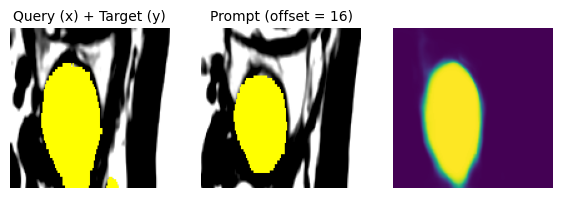

Creating new Data Points ...
It took 447 seconds
Epoch  181  loss: 0.064958
Epoch  182  loss: 0.062078
Epoch  183  loss: 0.062127
Epoch  184  loss: 0.060560
Epoch  185  loss: 0.059992
Epoch  186  loss: 0.058889
Epoch  187  loss: 0.059496
Epoch  188  loss: 0.058913
Epoch  189  loss: 0.058769
Epoch  190  loss: 0.057150
Epoch  191  loss: 0.057765
Epoch  192  loss: 0.057162
Epoch  193  loss: 0.056608
Epoch  194  loss: 0.055993
Epoch  195  loss: 0.055855
Epoch  196  loss: 0.055228
Epoch  197  loss: 0.055075
Epoch  198  loss: 0.056165
Epoch  199  loss: 0.054828
Epoch  200  loss: 0.054738
Epoch  201  loss: 0.054166
Epoch  202  loss: 0.053520
Epoch  203  loss: 0.052870
Epoch  204  loss: 0.052668
Epoch  205  loss: 0.052747
Epoch  206  loss: 0.052933
Epoch  207  loss: 0.053293
Epoch  208  loss: 0.052661
Epoch  209  loss: 0.053158
Epoch  210  loss: 0.052041


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.60946137..2.2615364].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.611257..2.2102568].


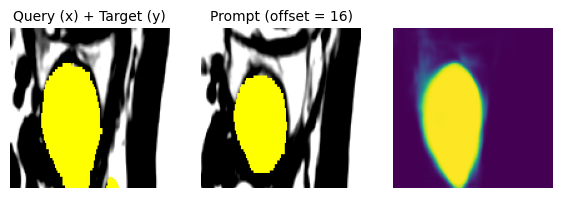

Creating new Data Points ...
It took 345 seconds
Epoch  211  loss: 0.067912
Epoch  212  loss: 0.065270
Epoch  213  loss: 0.063588
Epoch  214  loss: 0.062669
Epoch  215  loss: 0.062075
Epoch  216  loss: 0.062119
Epoch  217  loss: 0.061664
Epoch  218  loss: 0.061726
Epoch  219  loss: 0.060890
Epoch  220  loss: 0.060726
Epoch  221  loss: 0.059789
Epoch  222  loss: 0.058903
Epoch  223  loss: 0.058611
Epoch  224  loss: 0.058733
Epoch  225  loss: 0.057776
Epoch  226  loss: 0.057701
Epoch  227  loss: 0.057594
Epoch  228  loss: 0.057978
Epoch  229  loss: 0.057789
Epoch  230  loss: 0.057513
Epoch  231  loss: 0.056628
Epoch  232  loss: 0.056136
Epoch  233  loss: 0.055672
Epoch  234  loss: 0.055958
Epoch  235  loss: 0.056258
Epoch  236  loss: 0.056506
Epoch  237  loss: 0.055239
Epoch  238  loss: 0.054656
Epoch  239  loss: 0.054697
Epoch  240  loss: 0.054986


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.60946137..2.2615364].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.611257..2.2102568].


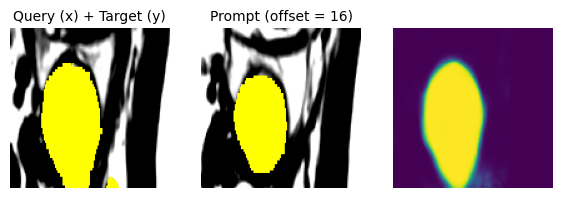

Creating new Data Points ...
It took 456 seconds
Epoch  241  loss: 0.063719
Epoch  242  loss: 0.060236
Epoch  243  loss: 0.059143
Epoch  244  loss: 0.058618
Epoch  245  loss: 0.057594
Epoch  246  loss: 0.056302
Epoch  247  loss: 0.056097
Epoch  248  loss: 0.055806
Epoch  249  loss: 0.054412
Epoch  250  loss: 0.054373
Epoch  251  loss: 0.053614
Epoch  252  loss: 0.053017
Epoch  253  loss: 0.052700
Epoch  254  loss: 0.051832
Epoch  255  loss: 0.052766
Epoch  256  loss: 0.052181
Epoch  257  loss: 0.052037
Epoch  258  loss: 0.053088
Epoch  259  loss: 0.052066
Epoch  260  loss: 0.050823
Epoch  261  loss: 0.050344
Epoch  262  loss: 0.049838
Epoch  263  loss: 0.050868
Epoch  264  loss: 0.051038
Epoch  265  loss: 0.049671
Epoch  266  loss: 0.048780
Epoch  267  loss: 0.049431
Epoch  268  loss: 0.049147
Epoch  269  loss: 0.048283
Epoch  270  loss: 0.049058


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.60946137..2.2615364].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.611257..2.2102568].


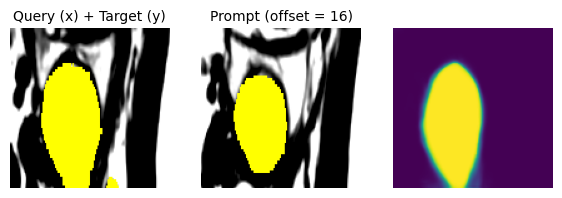

Creating new Data Points ...
It took 571 seconds
Epoch  271  loss: 0.071798
Epoch  272  loss: 0.068538
Epoch  273  loss: 0.066748
Epoch  274  loss: 0.066252


In [ ]:
def fit(epochs):
    mlflow.set_experiment(version)

    with mlflow.start_run():

        mlflow.log_params({
            "batch_size"        : batch_size,
            "max_number_labels" : max_number_labels,
            "num_epochs"        : epochs,
            "dp_training"       : dp_training,
            "offset"            : offset,
            "loss_function"     : "binary_crossentropy",
            "new_ds"            : new_ds,
            "warmup_epochs"     : warmup_epochs,
            "flat_epochs"       : flat_epochs,
            "prob_geometric"    : augmenter.prob_geometric,
            "prob_morph"        : augmenter.prob_morph,
            "gamma_range"       : str(augmenter.gamma_range),
            "trainable_params"  : model.this.count_params(),
        })

        # ── Validation dataset (built once, no augmentation) ───────────────────
        val_x, val_y, val_p, val_m, _ = datagenerator.get_val_data_points_numpy(
            max_data_points   = dp_testing,
            offset            = offset,
            max_number_labels = max_number_labels,
        )
        test_ds = (
            tf.data.Dataset.from_tensor_slices((val_x, val_y, val_p, val_m))
            .batch(1)
        )

        # ── Prime the training buffer before the loop ──────────────────────────
        refresh_train_data()

        for epoch in range(epochs):

            model.train_loss.reset_state()

            # Log learning rate
            lr = model.optimizer.learning_rate
            if isinstance(lr, tf.keras.optimizers.schedules.LearningRateSchedule):
                lr = float(lr(epoch * steps_per_epoch))
            else:
                lr = float(lr.numpy())
            mlflow.log_metric("learning_rate", lr, step=epoch)

            # Checkpoint every 8 epochs
            if epoch % 8 == 0 and epoch != 0:
                model.this.save(f"{version}.keras")

            # Validation every new_val_loop epochs
            if epoch % new_val_loop == 0 and epoch != 0:
                total_dice = 0.0
                for z in test_ds:
                    pred = model.this([z[0], z[2]], training=False)
                    total_dice += float(dice_score_tf(z[1][..., 0:1], pred))
                val_loss = 1.0 - total_dice / dp_testing
                mlflow.log_metric("validation_loss", val_loss, step=epoch)
                print(f"  Validation loss: {val_loss:.4f}")

            # Refresh training data every new_ds epochs
            if epoch % new_ds == 0 and epoch != 0:
                # Visualise one validation prediction
                z_test = next(iter(test_ds))
                pred   = model.this([z_test[0], z_test[2]], training=False)
                plot_result(z_test[0][0], z_test[1][0], z_test[2][0], pred[0], offset, "")

                # Swap numpy buffer — pipeline graph stays intact
                refresh_train_data()

            # Train one epoch
            model.train_epoch(train_dataset=train_ds)

            epoch_loss = float(model.train_loss.result())
            print(f"Epoch {epoch + 1:>4d}  loss: {epoch_loss:.6f}")
            mlflow.log_metric("train_loss", epoch_loss, step=epoch)


fit(epochs)